A parametric model of circumstellar disks 
---
See e.g. section 3.1 in https://ui.adsabs.harvard.edu/abs/2020ApJ...895..109F/abstract

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os, sys
import matplotlib
from pathlib import Path
from ruamel.yaml import YAML
from tqdm.auto import tqdm
from gofish import imagecube
from mpl_toolkits.axes_grid1 import make_axes_locatable
import emcee, corner
from collections import OrderedDict
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk, inference
from network import shard
from consts import *

In [2]:
def render_cube(ray_coords, pixel_area, disk, nd_co, temperature, velocity_az, bbox, freqs, nu0):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
    
    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)
    
    # Einstein coefficient for spontaneous emission from level u to level d
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk.transition)
    n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk.transition)

    alpha_tot = line_rte.alpha_total_co(disk.v_turb, gas_t, disk.m_mol)

    print('computing spectral cube for a total of {} frequencies'.format(freqs.size))
    images = line_rte.compute_spectral_cube_pmap(shard(freqs), gas_v, alpha_tot, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area)
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

velocity resolution: 158.7238509960007 m/s


interactive(children=(IntSlider(value=29, description='frame', max=59), Output()), _dom_classes=('widget-inter…

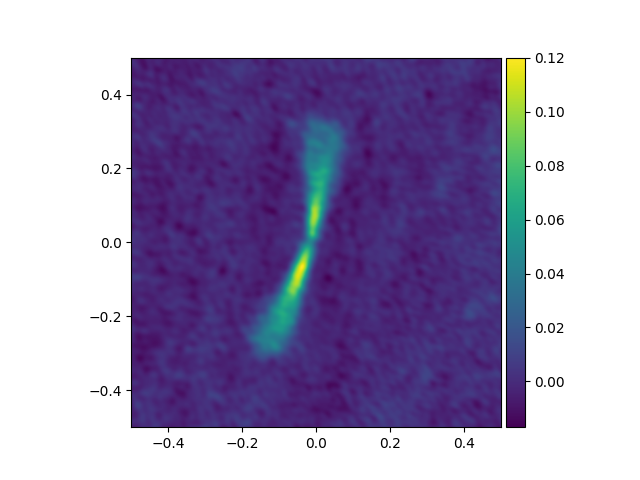

In [3]:
fov_as = 14.0   # arcsecs
num_freqs_resample = 60
data_path = '../data/alma/v4046_co21sblb.cm.fits'
data_dir = Path(data_path).parent
data_cube = imagecube(data_path, FOV=fov_as)

# resample cube a bit faster than 160 m/s
num_freqs = len(data_cube.freqax)
   
idx = np.round(np.linspace(0, num_freqs-1, num_freqs_resample)).astype(int)

data = data_cube.data[idx]
freqs = data_cube.freqax[idx]
velocities = data_cube.velax[idx]
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')

nu0 = data_cube.nu0
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
delta_v_ms = velocities[1] - velocities[0]
print('velocity resolution: {} m/s'.format(delta_v_ms))
      
# Center the velocities around n0 by removing systemic component
freqs += nu0 - freqs.mean()

%matplotlib widget
visualization.slider(data)

# Fiducial model

In [ ]:
def co_abundance_profile(self, N_h2, temperature):
    
    co_region = jnp.bitwise_and(
        temperature>self.freezeout, 
        jnp.bitwise_and(0.706*N_h2>self.N_dissoc_lo, 0.706*N_h2<self.N_dissoc_hi)
    )
    abundance = jnp.where(co_region, self.co_abundance, 0.0)
    return abundance 

In [19]:
import importlib
importlib.reload(parametric_disk)

<module 'parametric_disk' from '/scratch/imaging/projects/protoplanetary/radjax/notebooks/../parametric_disk.py'>

In [22]:
disk = parametric_disk.DiskFlaherty(
    name='v4041_CO(2-1)',
    q=-0.565,
    q_in=0,
    r_break=-np.inf,
    log_r_c=1.939,
    v_turb=0.15,
    T_atm1=27.84,
    gamma=1.0,
    T_mid1=12.0,
    M_star=1.75*M_sun,
    r_in=7.0,
    M_gas=0.046*M_sun,
    co_abundance=3e-6,
    N_dissoc_lo=1.3e21,
    N_dissoc_hi=4.8e21,
    freezeout=20.0,
    r_scale=150.0,
    z_q0=35.0,
    delta=1,
    transition=2,
    m_mol=2.37*m_h,
    molecule_table='../molecular_tables/molecule_12c16o.inp',
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk.r_in, 800
z_disk, r_disk = jnp.meshgrid(jnp.linspace(z_min, z_max, resolution), jnp.linspace(r_min, r_max, resolution), indexing='ij')

temperature = disk.temperature_profile(z_disk, r_disk)
nd_h2 = parametric_disk.number_density_profile(z_disk, r_disk, temperature, disk.gamma, disk.r_in, 10**disk.log_r_c, disk.M_gas, disk.M_star, disk.m_mol)
velocity_az = disk.velocity(z_disk, r_disk, nd_h2, temperature)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

# Compute the relative abundance of co
abundance_co = disk.co_abundance_profile(N_h2, temperature)
nd_co = abundance_co * nd_h2

In [5]:
projection = sensor.PinholeProjection(
    name=disk.name,
    x_sky=x_sky,
    y_sky=y_sky,
    distance=72.26, 
    nray=100,
    incl=34.69,
    phi=0.0,
    posang=75.7,
    z_width=2*z_max,
    freqs=freqs
)
# Bounding box for interpolations
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])
beam = data_cube.beams_per_pix * sensor.beam(data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa)

fov_rad =  fov_as*arcsec                  # field of view 
fov = 2 * projection.distance*pc * np.tan(fov_rad/2.0)  # gives ~1708 [au]
pixel_area = (fov/npix)**2
ray_coords, obs_dir = sensor.pinhole_disk_projection(
    projection.x_sky, projection.y_sky, projection.distance, projection.nray, 
    projection.incl, projection.phi, projection.posang, projection.z_width
)

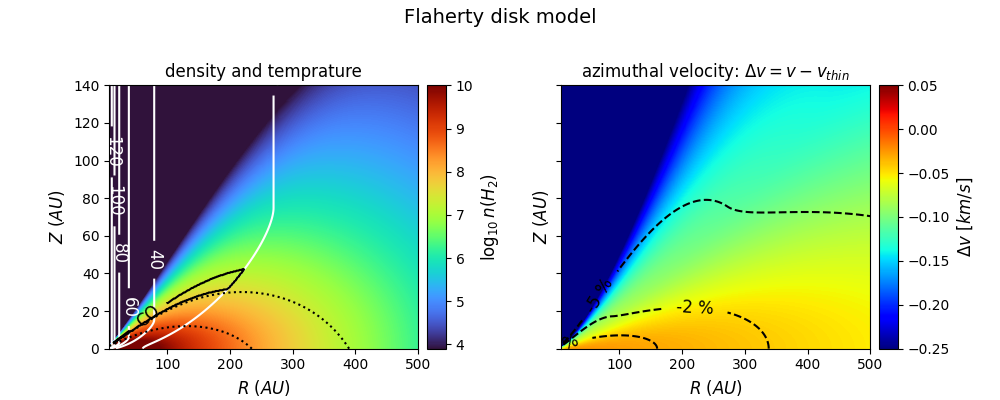

In [23]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);

divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co, levels=[disk.co_abundance/2], colors='black')
axes[0].clabel(cp, levels=[disk.co_abundance/2], fmt='CO', inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')


# Plot azimuthal velocity 
v_thin = np.sqrt(parametric_disk.vsq_keplerian_thin_disk(r_disk, disk.M_star))
delta_v = (velocity_az-v_thin)
im = axes[1].imshow(1e-5*delta_v, cmap='jet', vmin=-0.25, vmax=0.05, origin='lower', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], aspect=3)
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\Delta v~[km/s]$', fontsize=12)
cp = axes[1].contour(r_disk, z_disk, 100*delta_v/velocity_az, levels=[-5, -2, -1], colors='black')
plt.clabel(cp, [-5, -2, -1], inline=True, fontsize=12, fmt=lambda x:'{:.0f} %'.format(x));

for ax in axes:
    ax.set_xlabel(r'$R~(AU)$', fontsize=12)
    ax.set_ylabel(r'$Z~(AU)$', fontsize=12)
    ax.set_xlim(r_disk.min(),500)
    ax.set_ylim(0,140)

axes[0].set_title('density and temprature')
axes[1].set_title(r'azimuthal velocity: $\Delta v = v-v_{thin}$')
plt.suptitle('Flaherty disk model', fontsize=14, y=0.98);
plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

interactive(children=(IntSlider(value=29, description='frame', max=59), Output()), _dom_classes=('widget-inter…

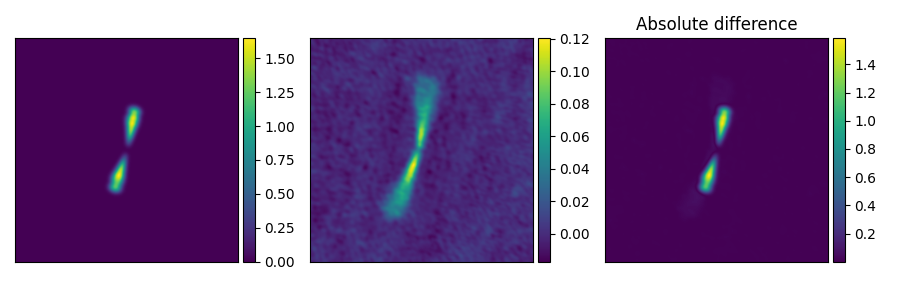

In [114]:
visualization.slider_frame_comparison(images_blurred, data)

computing spectral cube for a total of 60 frequencies


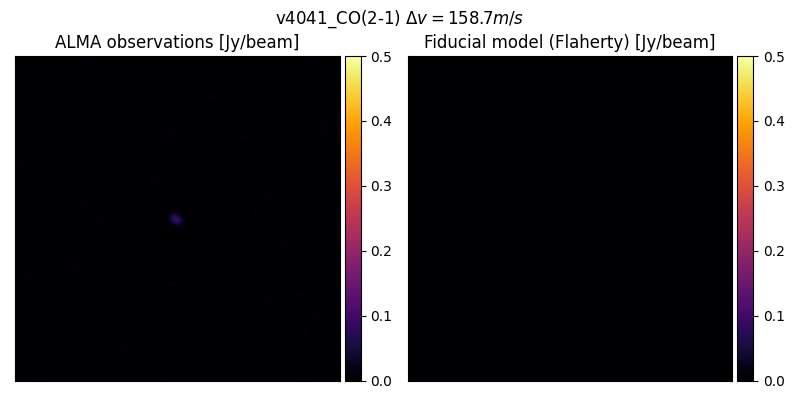

In [24]:
# Render spectral cube and convolve with gaussian beam
images = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, velocity_az, bbox_disk, freqs, nu0)
images_blurred = sensor.fftconvolve_vmap(images, beam)

# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(1,2,figsize=(8,4))
fig.suptitle(r'{} $\Delta v = {:2.1f} m/s$'.format(disk.name, delta_v_ms))
titles = [r'ALMA observations [Jy/beam]', r'Fiducial model (Flaherty) [Jy/beam]']
visualization.animate_movies_synced([data, np.array(images_blurred)], axes, vmin=[0,0], vmax=[0.5]*2, 
                                    titles=titles, cmaps='inferno', fps=5, 
                                    output=data_path.replace('fits', 'Flaherty.gif'))

# Parameter inference using `emcee`

In [23]:
# EMCEE expands better than contract 10^-3 cluster
run_name = 'mcmc_2017_params'
posterior_params = OrderedDict(
    q=[-0.5, 0],
    log_r_c=[1.75 ,2.5],
    v_turb=[0.0, 1.0],
    T_atm1=[40, 150],
    T_mid1=[5, 40],
    r_in=[1,20],
    r_break=[15, 115],
    q_in=[-1, 0]
)
param_names = list(posterior_params.keys())

sigma = 0.05     # 5 mJy is ~1% noise level (peak of 0.5Jy)
stride = 5   # beam FWHM is ~10 pixels across, skipping every 5th pixels to fit `spatially independent` pixels

# Save sampler params to a yaml file
yaml = YAML(typ='safe')
yaml.default_flow_style = False
filename = data_dir.joinpath('recovery/{}/{}_posterior_params.yaml'.format(disk.name, run_name))
os.makedirs(os.path.dirname(filename), exist_ok=True)
with open(filename, 'w') as file:
    yaml.dump(posterior_params, file)
    
# Initialize the sampler
ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)

disk_sampler = inference.DiskSampler(
    z_disk, r_disk, bbox_disk, pixel_area, ray_coords, ray_coords_polar, obs_dir, 
    beam, energy_levels, radiative_transitions, sigma, disk, stride, posterior_params
)

seed = 63
ndim, nwalkers = len(posterior_params), 80
p0 = disk_sampler.sample_p0(posterior_params, nwalkers, seed=seed)

# Set up the backend
filename = data_dir.joinpath('recovery/{}/{}_sampler.h5'.format(disk.name, run_name))
backend = emcee.backends.HDFBackend(filename)
backend.reset(nwalkers, ndim)

# logprob = jax.vmap(disk_sampler.logprob, in_axes=(None, 0, 0))
sampler = emcee.EnsembleSampler(nwalkers, ndim, disk_sampler.logprob, args=[data, freqs], backend=backend)

setting inital seed to: 63


In [24]:
# run initial chain to find area of high probability
num_iter = 2000
num_iter_restart = 100
restart_cluster_size = 1e-2

run_params = {
    'data_path': data_path,
    'seed': seed,
    'sigma': sigma,
    'stride': stride, 
    'nwalkers': nwalkers,
    'num_iter_restart': num_iter_restart,
    'restart_cluster_size': restart_cluster_size
    
}

with open(data_dir.joinpath('recovery/{}/{}_run_params.yaml'.format(disk.name, run_name)), 'w') as file:
    yaml.dump(run_params, file)
    
state = sampler.run_mcmc(p0, num_iter_restart, progress=True)
flat_samples = sampler.get_chain(flat=True)
median = np.median(flat_samples, axis=0)

# run starting from a small cluster around the median
p1 = np.random.normal(median,  restart_cluster_size * np.abs(median), size=(nwalkers, ndim))
state = sampler.run_mcmc(p1, num_iter, progress=True)

 61%|████████████████████████████████████████████████████████▍                                    | 1213/2000 [1:59:18<1:17:24,  5.90s/it]Traceback (most recent call last):
  File "/srv/tmp/aviad/miniconda3/envs/jax/lib/python3.12/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
 61%|████████████████████████████████████████████████████████▍                                    | 1213/2000 [1:59:23<1:17:27,  5.91s/it]

emcee: Exception while calling your likelihood function:
  params: [-2.47402612e-01  2.20309725e+00  1.05912677e-03  8.19904870e+01
  2.03887294e+01  1.59659226e+01  5.89963320e+01 -4.27723661e-01]
  args: [array([[[-2.1933028e-03, -2.1846779e-03, -2.4876231e-03, ...,
         -8.1100315e-04,  1.7223330e-03,  4.2312099e-03],
        [-3.7504658e-03, -3.8926937e-03, -4.3427031e-03, ...,
          3.1215046e-04,  2.6458306e-03,  4.8472630e-03],
        [-5.1249173e-03, -5.4935552e-03, -6.1620986e-03, ...,
          9.4094733e-04,  3.0423226e-03,  4.9545583e-03],
        ...,
        [-1.7457023e-02, -2.0644302e-02, -2.2324475e-02, ...,
         -1.5451496e-03,  8.5163978e-05,  5.4474059e-04],
        [-1.6935240e-02, -2.0439789e-02, -2.2668015e-02, ...,
         -2.7521979e-03, -1.7740307e-03, -2.0029489e-03],
        [-1.6033269e-02, -1.9587843e-02, -2.2130946e-02, ...,
         -3.9599403e-03, -3.6746883e-03, -4.5447969e-03]],

       [[ 9.1812946e-03,  1.1163867e-02,  1.2535905e-02, .

KeyboardInterrupt: 

# Load and plot `emcee` chains

In [25]:
runname = 'mcmc_2017_params'
directory = Path('../data/alma/recovery/HD163296_CO(2-1)')
sampler_file = directory.joinpath('{}_sampler.h5'.format(runname))
yaml_file = directory.joinpath('{}_posterior_params.yaml'.format(runname))
reader = emcee.backends.HDFBackend(sampler_file)

yaml = YAML(typ='safe')
with open(yaml_file, 'r') as stream:
    posterior_params = yaml.load(stream)
param_names = list(posterior_params.keys())

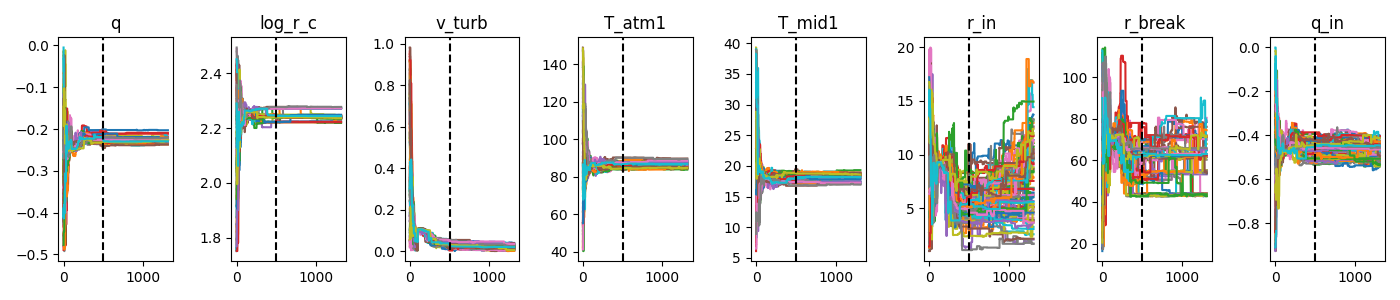

In [26]:
discard = 500
thin = 15
chain = reader.get_chain()
flat_samples = reader.get_chain(discard=discard, thin=thin, flat=True)

ndim = chain.shape[-1]


%matplotlib widget
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_names[i])
    axes[i].axvline(discard, color='black', linestyle='--')

plt.tight_layout()

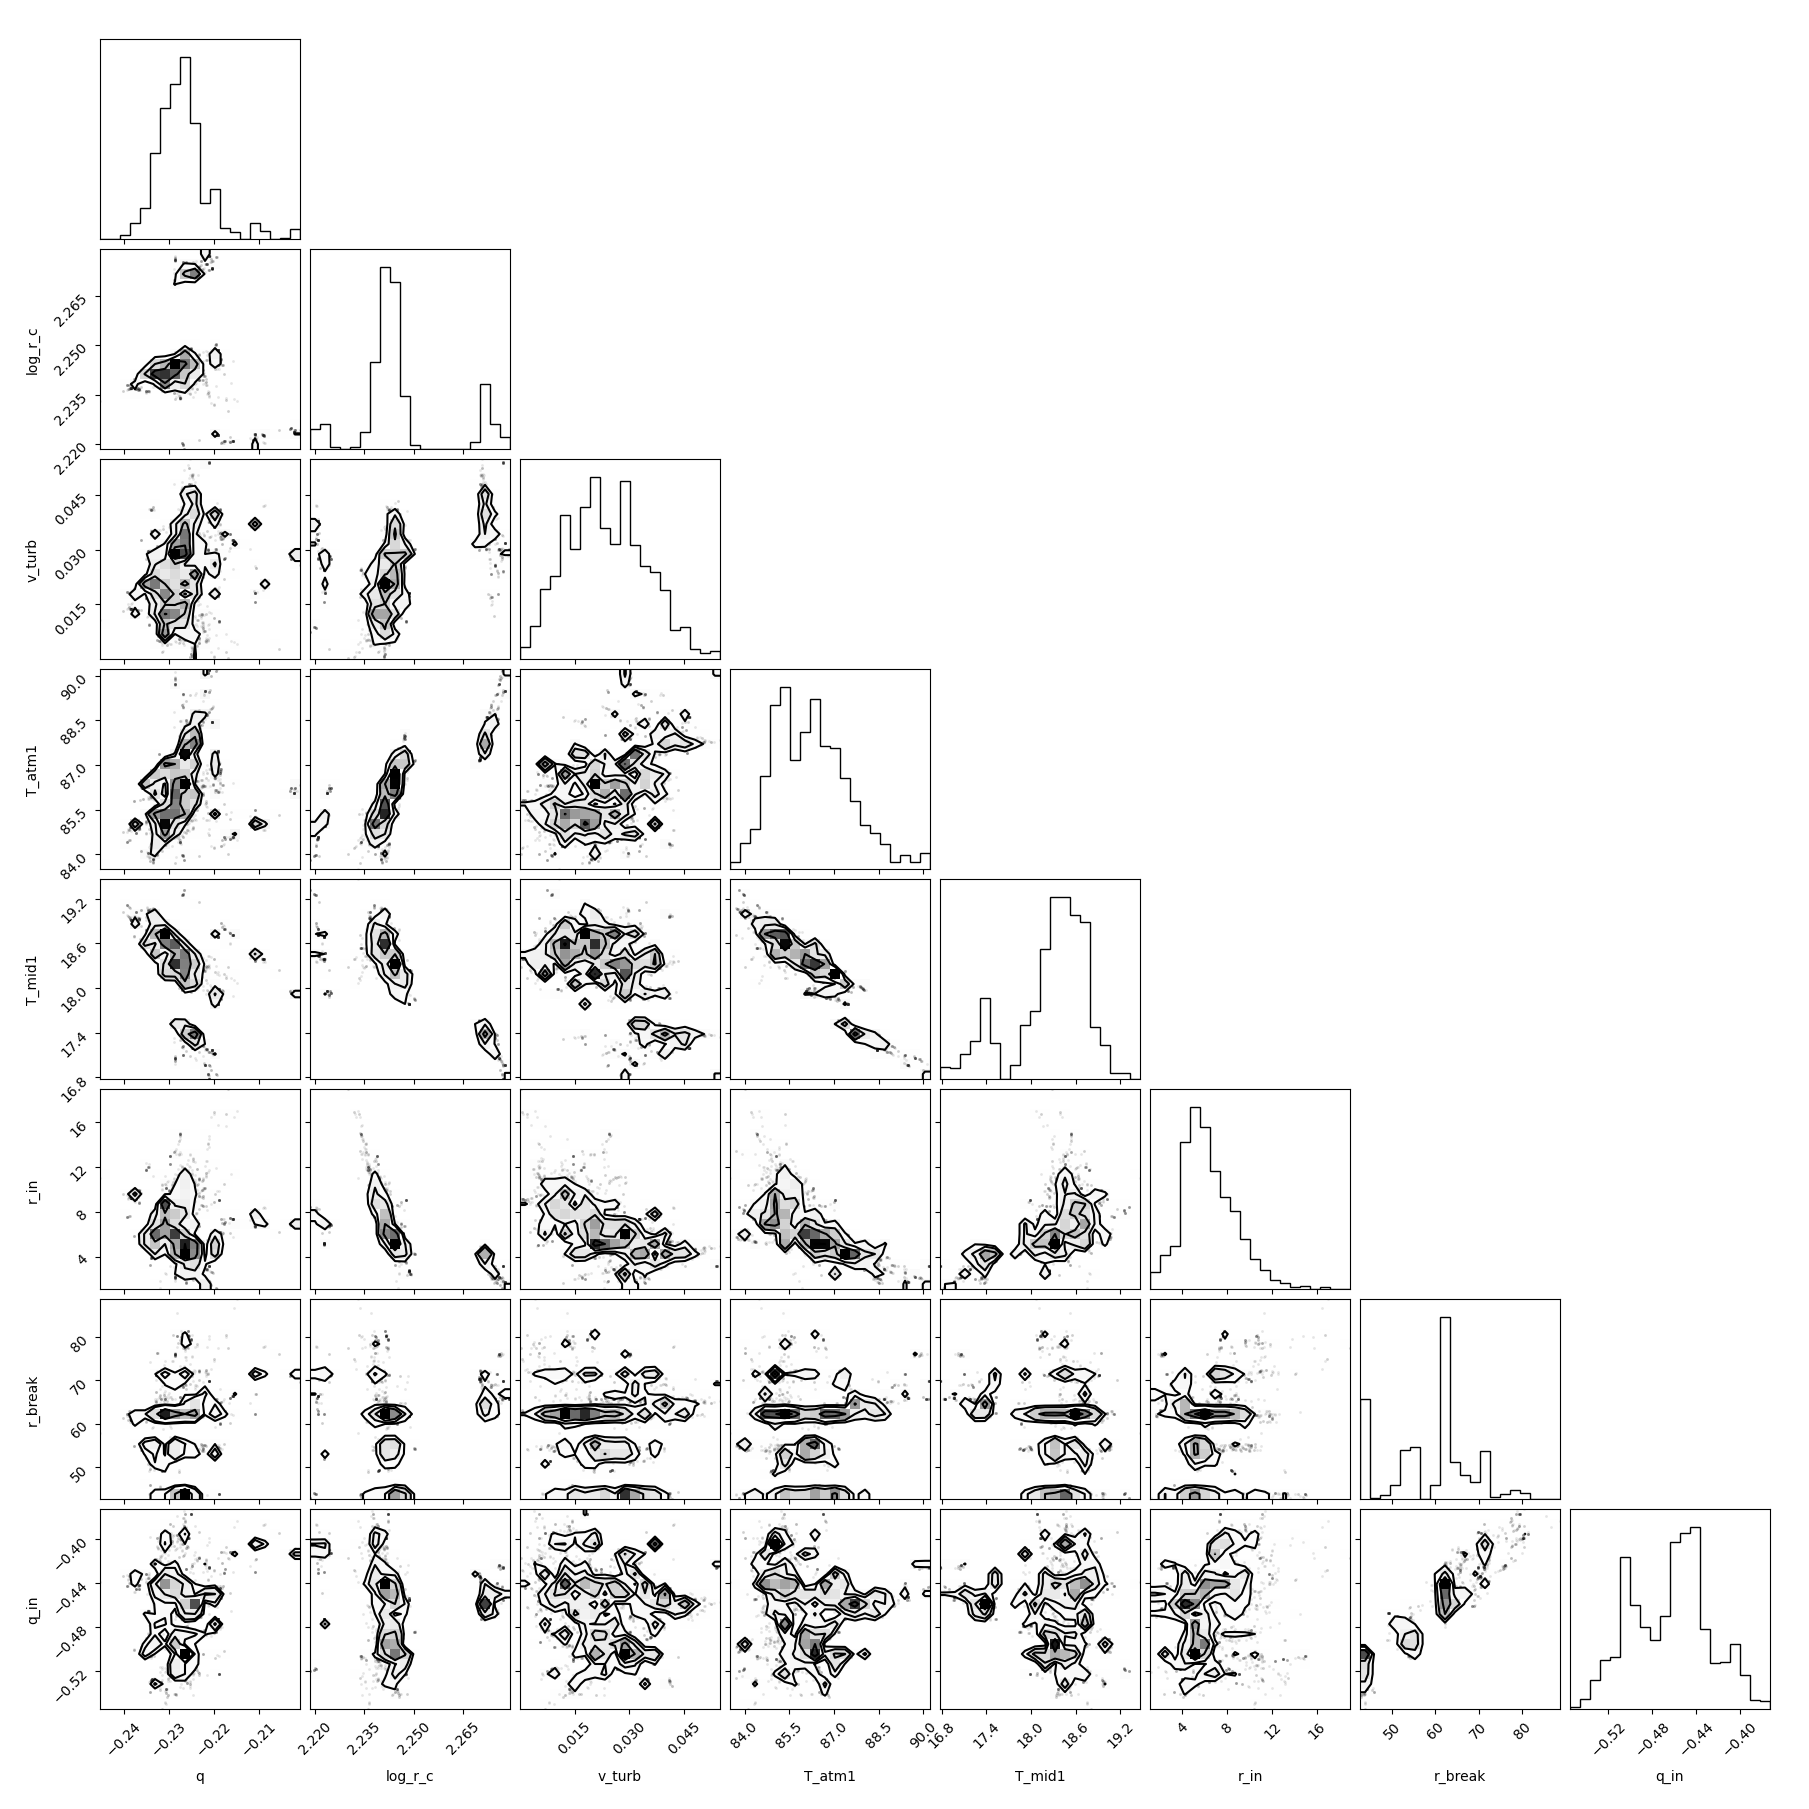

In [27]:
%matplotlib widget
fig = corner.corner(data=flat_samples, labels=param_names)

In [30]:
from IPython.display import display, Math

print('Uncertainties based on the 16th, 50th, and 84th percentiles of the samples in the marginalized distributions.')
param_names[1] = 'log(R_c)'
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], param_names[i])
    display(Math(txt))

Uncertainties based on the 16th, 50th, and 84th percentiles of the samples in the marginalized distributions.


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Estimated disk from median parameters

In [13]:
disk = parametric_disk.DiskFlaherty(
    name='HD163296_CO(2-1)',
    q=-0.27,
    r_c=224.0,
    v_turb=0.31,
    T_atm1=79.0,
    gamma=1.0,
    T_mid1=17.5,
    M_star=2.3*M_sun,
    r_in=9.0,
    M_gas=0.09*M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79*1.59e21,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37*m_h,
    molecule_table='../molecular_tables/molecule_12c16o.inp',
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk.r_in, 800
z_disk, r_disk = jnp.meshgrid(jnp.linspace(z_min, z_max, resolution), jnp.linspace(r_min, r_max, resolution), indexing='ij')

temperature = disk.temperature_profile(z_disk, r_disk)
nd_h2 = parametric_disk.number_density_profile(z_disk, r_disk, temperature, disk.gamma, disk.r_in, disk.r_c, disk.M_gas, disk.M_star, disk.m_mol)
velocity_az = disk.velocity(z_disk, r_disk, nd_h2, temperature)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

# Compute the relative abundance of co
abundance_co = disk.co_abundance_profile(N_h2, temperature)
nd_co = abundance_co * nd_h2

projection = sensor.PinholeProjection(
    name=disk.name,
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0, 
    nray=100,
    incl=46.1,
    phi=0.0,
    posang=312.0,
    z_width=2*z_max,
    freqs=freqs
)
# Bounding box for interpolations
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])
beam = data_cube.beams_per_pix * sensor.beam(data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa)

fov_rad =  fov_as*arcsec                  # field of view 
fov = 2 * projection.distance*pc * np.tan(fov_rad/2.0)  # gives ~1708 [au]
pixel_area = (fov/npix)**2
ray_coords, obs_dir = sensor.pinhole_disk_projection(
    projection.x_sky, projection.y_sky, projection.distance, projection.nray, 
    projection.incl, projection.phi, projection.posang, projection.z_width
)


In [14]:
# Recovered disk
mcmc_median = np.median(flat_samples, axis=0)
disk_rj = disk.__copy__(name='HD163296_CO(2-1) radjax')
disk_rj.update(param_names, mcmc_median)
temperature_rj = disk_rj.temperature_profile(z_disk, r_disk)
nd_h2_rj = parametric_disk.number_density_profile(z_disk, r_disk, temperature, disk_rj.gamma, disk_rj.r_in, disk_rj.r_c, disk_rj.M_gas, disk_rj.M_star, disk_rj.m_mol)
velocity_az_rj = disk_rj.velocity(z_disk, r_disk, nd_h2_rj, temperature_rj)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2_rj = parametric_disk.surface_density(z_disk, nd_h2_rj)
sigma_h2_rj = N_h2_rj * m_h

# Compute the relative abundance of co
abundance_co_rj = disk.co_abundance_profile(N_h2_rj, temperature_rj)
nd_co_rj = abundance_co_rj * nd_h2_rj

# Render spectral cube and convolve with gaussian beam
images_fl = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, -velocity_az, bbox_disk, freqs, nu0)
images_blurred_fl = sensor.fftconvolve_vmap(images_fl, beam)

images_rj = render_cube(ray_coords, pixel_area, disk_rj, nd_co_rj, temperature_rj, -velocity_az, bbox_disk, freqs, nu0)
images_blurred_rj = sensor.fftconvolve_vmap(images_rj, beam)

computing spectral cube for a total of 60 frequencies
computing spectral cube for a total of 60 frequencies


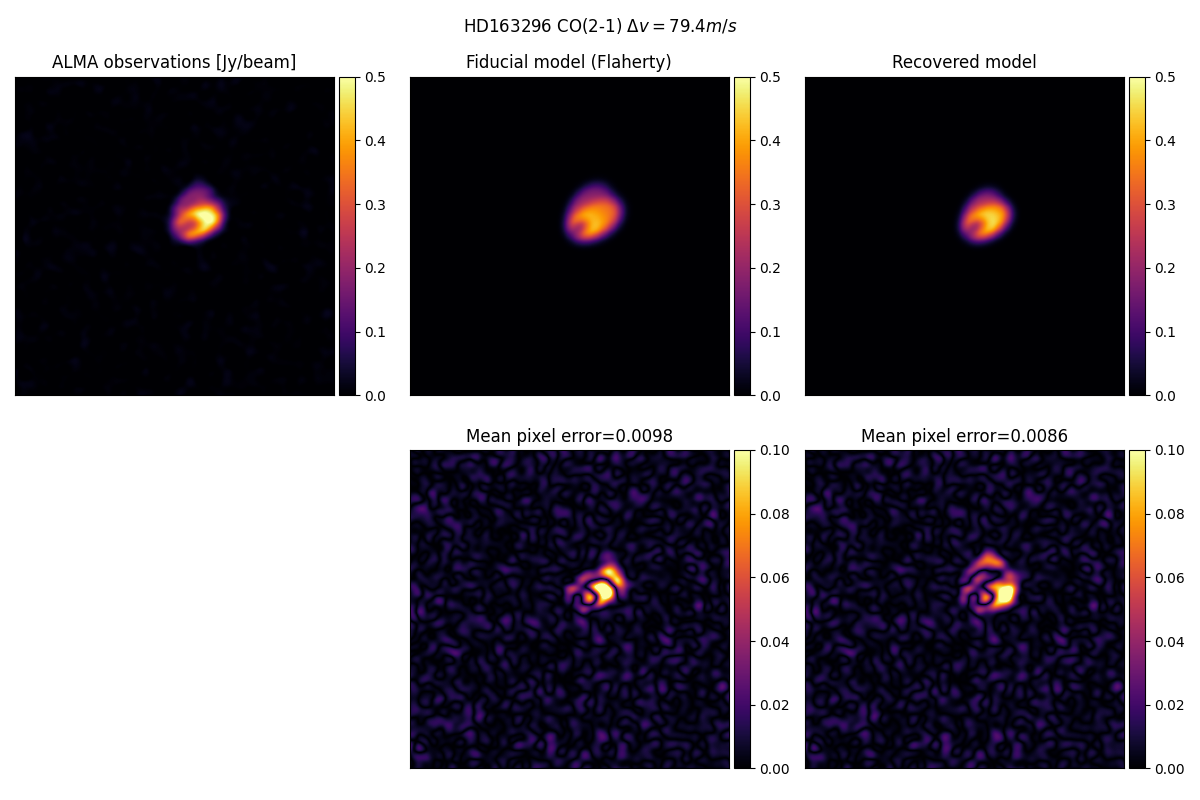

In [19]:
output = directory.joinpath(runname + '.gif')

# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(2,3,figsize=(12,8))
axes[1,0].axis("off")
axes_list = list(axes[0]) + list(axes[1,1:])

data_fit_fl = np.abs(data - images_blurred_fl).mean()
data_fit_rj = np.abs(data - images_blurred_rj).mean()
fig.suptitle(r'HD163296 CO(2-1) $\Delta v = {:2.1f} m/s$'.format(delta_v_ms))
titles = [r'ALMA observations [Jy/beam]', r'Fiducial model (Flaherty)', 'Recovered model', 
          r'Mean pixel error={:1.4f}'.format(data_fit_fl), r'Mean pixel error={:1.4f}'.format(data_fit_rj)]
movies = [data, np.array(images_blurred_fl), np.array(images_blurred_rj),
         np.abs(data - images_blurred_fl), np.abs(data - images_blurred_rj)]
visualization.animate_movies_synced(
    movies, axes_list, vmin=[0,0,0,0,0,0], vmax=[0.5,0.5,0.5,0.1,0.1], 
    titles=titles, cmaps='inferno', fps=3, output=output, writer='ffmpeg'
)

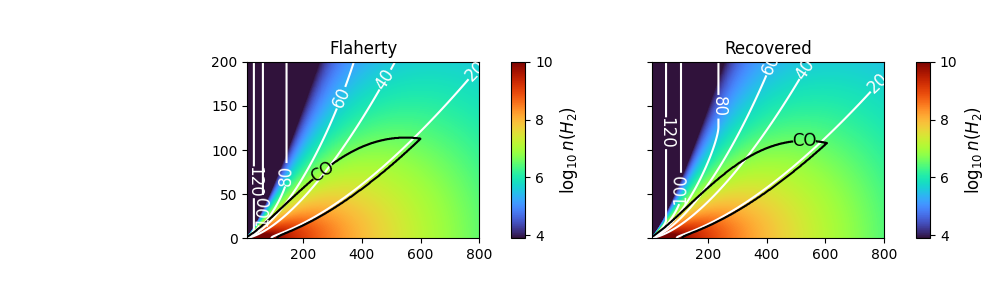

In [26]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,3), sharey=True)

for ax, nd, temp, abund in zip(axes, [nd_h2, nd_h2_rj], [temperature, temperature_rj], [abundance_co, abundance_co_rj]):
    im = ax.imshow(np.log10(nd), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='2%', pad=-2)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

    levels = [20, 40, 60, 80, 100, 120]
    cp = ax.contour(r_disk, z_disk, temp, levels, colors='white')
    ax.clabel(cp, levels, inline=1, fontsize=12);
    cp = ax.contour(r_disk, z_disk, abund, levels=[5e-5], colors='black')
    ax.clabel(cp, levels=[5e-5], fmt='CO', inline=1, fontsize=12);

axes[0].set_title('Flaherty')
axes[1].set_title('Recovered')
plt.tight_layout()

In [31]:
from IPython.display import display, Math
sigma = 5e-3

num_dof = len(posterior_params)
reduced_chi2_fl = np.mean(((images_blurred_fl - data)/sigma)**2) / num_dof
txt = "\chi^2_{{\mathrm{{Flaherty}}}} = {}"
txt = txt.format(reduced_chi2_fl)
display(Math(txt))

reduced_chi2_rj = np.mean(((images_blurred_rj - data)/sigma)**2) / num_dof
txt = "\chi^2_{{\mathrm{{radjax}}}} = {}"
txt = txt.format(reduced_chi2_rj)
display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>